In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Team "Dreaddit"

Luka, Blake, Avery, Eddy

Dataset name: "Dreaddit"

Target variable: stress as binary classification, given by "label" in the dataset, 1 is stressed, 0 is not.


1. Problem and Data
Dataset: dreaddit-train.csv

Machine learning problem: Identify whether a social media user is stressed based on their post

Target variable: stress as a binary classification, given by "label" in the dataset, 1 is stressed, 0 is not. The input data had users rate posts as Stress, Not stress, or can't tell, and then each segment was labeled for the percentage of people who agreed.

The Input features we will be using are:
Text: The text of the user post
Sentiment: Sentiment of the post generated using the patterns sentiment analysis library

lex_liwc_I: Measures the use of first-person singular pronouns, often linked to self-focus.
lex_liwc_Negemo: Tracks "Negative Emotion" words, helping the model identify how many negative terms a user wrote.
lex_liwc_Anx: Specifically captures "Anxiety"-related vocabulary.
lex_liwc_Risk: Measures words associated with "Risk" and uncertainty.

(lex: LIWC tool, categorizes words into psychologically meaningful groups)

The output feature we will be using is Label (Stressed/not stressed)

2. Exploratory Data Analysis

There doesn’t seem to be super high correlation with any of the variables. The highest correlation was negmo, and anxiety, the lowest was negmo and sentiment.

3. Data Quality and Cleaning

We took a random sample of 10% of the training set, because we are working on laptops. We will increase the size when our model is more established.
Our data was very clean; it contained no erroneous data. There were no missing values, no missing data labels, no duplicate records, and no clearly invalid entries. Some of the data has a low confidence score, but for the most part, it looks pretty good.

4. Modeling Readiness Reflection

We expect there to be some challenges in working with a large amount of data. The full training data contains 2929 different posts. Additionally, some of our features were generated using lexical features calculated from data in the dictionary of affect in language (DAL) and sentiment calculated using the pattern sentiment library. We believe sentiment and negemo will be useful features. Sentiment will give us a general sentiment rating of an entire post, which will be helpful to use with other features, and negemo will let us understand how many negative words the user wrote. Stress is a complex and multifaceted topic, and there are many factors that affect it.
We found a few important patterns. First of all, sentiment and I pronoun seem to follow a normal distribution. Negative emotion seems to be left skewed and Anxiety and risk seem to be bimodal.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df_initial = pd.read_csv("/content/dreaddit_data/dreaddit-train.csv")
df = df_initial.sample(frac=0.10, random_state=42)
df.head()

,subreddit,post_id,sentence_range,text,id,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment
415,anxiety,82dnj5,"[10, 15]","For anxiety/depression. Feb 16 weekend, we hun...",1948,0,1.0,1520326191,2,5.506316,...,1.2308,1.2500,1.0,1.71123,1.49811,1.91967,1.00,2,6.452491,0.065625
2691,anxiety,78tayl,"(15, 20)",His response was to constantly remind me that ...,14188,0,0.8,1508992437,2,8.301111,...,1.1250,1.1429,1.0,1.71269,1.46234,1.88361,0.76,0,7.044049,0.150000
1322,survivorsofabuse,9vm1x4,"(10, 15)",He would call me by the name peepee until I wa...,18982,1,1.0,1541782192,50,0.770870,...,1.0000,1.2000,1.0,1.76491,1.70000,1.80252,0.96,15,2.576159,-0.625000
2272,homeless,97on6i,"[0, 5]","Back ground, me and my girl have been homeless...",132,1,0.6,1534388303,23,6.235398,...,1.1429,1.1667,1.0,1.71735,1.55584,1.79863,0.96,59,6.520398,0.074242
1967,relationships,7u4g0w,"[20, 25]","Sally is around the same age, 25 I assume, (ca...",331,0,1.0,1517347438,1,6.495490,...,1.1429,1.1429,1.0,1.70341,1.45918,1.89157,0.67,11,7.018950,0.058886


In [5]:
df["text"].isna().sum()
df["sentiment"].isna().sum()
df["lex_liwc_negemo"].isna().sum()
df["lex_liwc_negemo"].isna().sum()
df["lex_liwc_risk"].isna().sum()
df["lex_liwc_anx"].isna().sum()



np.int64(0)

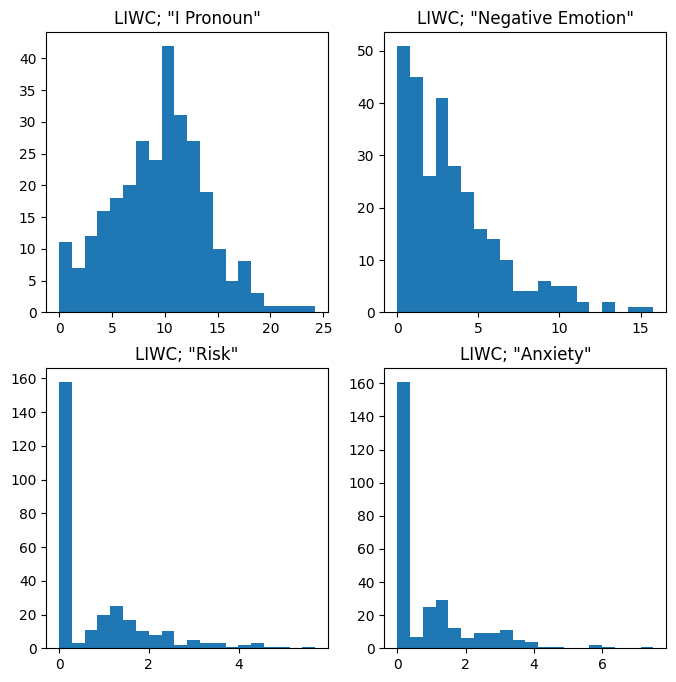

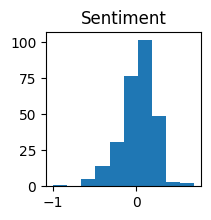

In [6]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.hist(df["lex_liwc_i"], bins=20)
plt.title("LIWC; \"I Pronoun\"")
plt.subplot(2,2,2)
plt.hist(df["lex_liwc_negemo"], bins=20)
plt.title("LIWC; \"Negative Emotion\"")
plt.subplot(2,2,3)
plt.hist(df["lex_liwc_risk"], bins=20)
plt.title("LIWC; \"Risk\"")
plt.subplot(2,2,4)
plt.hist(df["lex_liwc_anx"], bins=20)
plt.title("LIWC; \"Anxiety\"")

plt.figure(figsize=(2,2))
plt.hist(df["sentiment"])
plt.title("Sentiment")

plt.show()
plt.close()

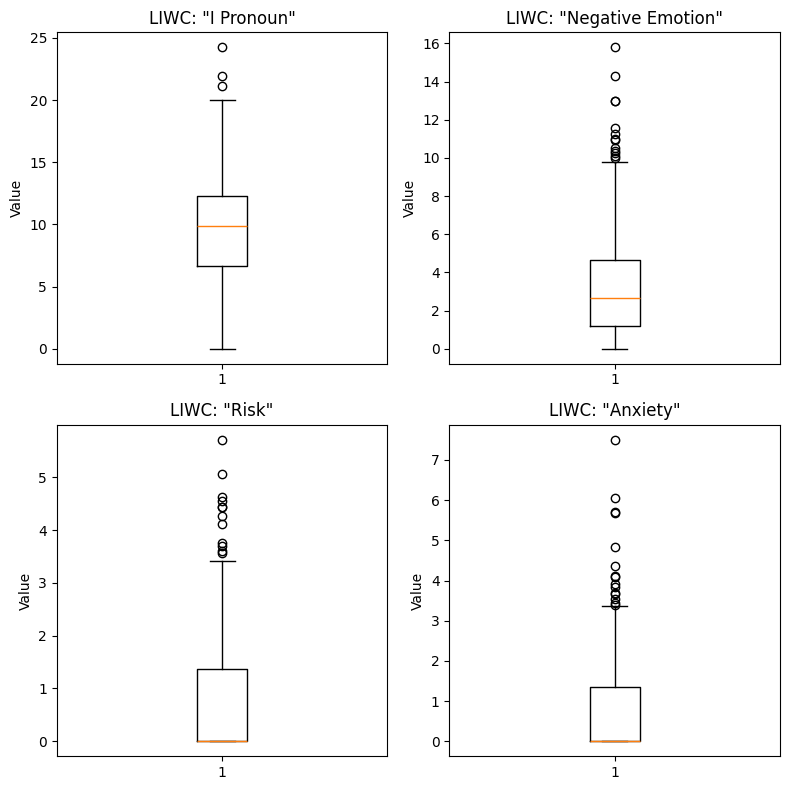

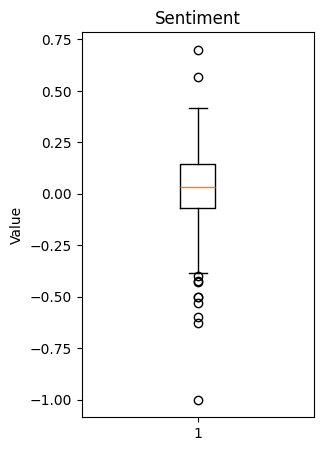

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.boxplot(df["lex_liwc_i"].dropna())
plt.title('LIWC: "I Pronoun"')
plt.ylabel("Value")

plt.subplot(2, 2, 2)
plt.boxplot(df["lex_liwc_negemo"].dropna())
plt.title('LIWC: "Negative Emotion"')
plt.ylabel("Value")

plt.subplot(2, 2, 3)
plt.boxplot(df["lex_liwc_risk"].dropna())
plt.title('LIWC: "Risk"')
plt.ylabel("Value")

plt.subplot(2, 2, 4)
plt.boxplot(df["lex_liwc_anx"].dropna())
plt.title('LIWC: "Anxiety"')
plt.ylabel("Value")

plt.tight_layout()
plt.show()
plt.close()

plt.figure(figsize=(3, 5))
plt.boxplot(df["sentiment"].dropna())
plt.title("Sentiment")
plt.ylabel("Value")

plt.show()
plt.close()

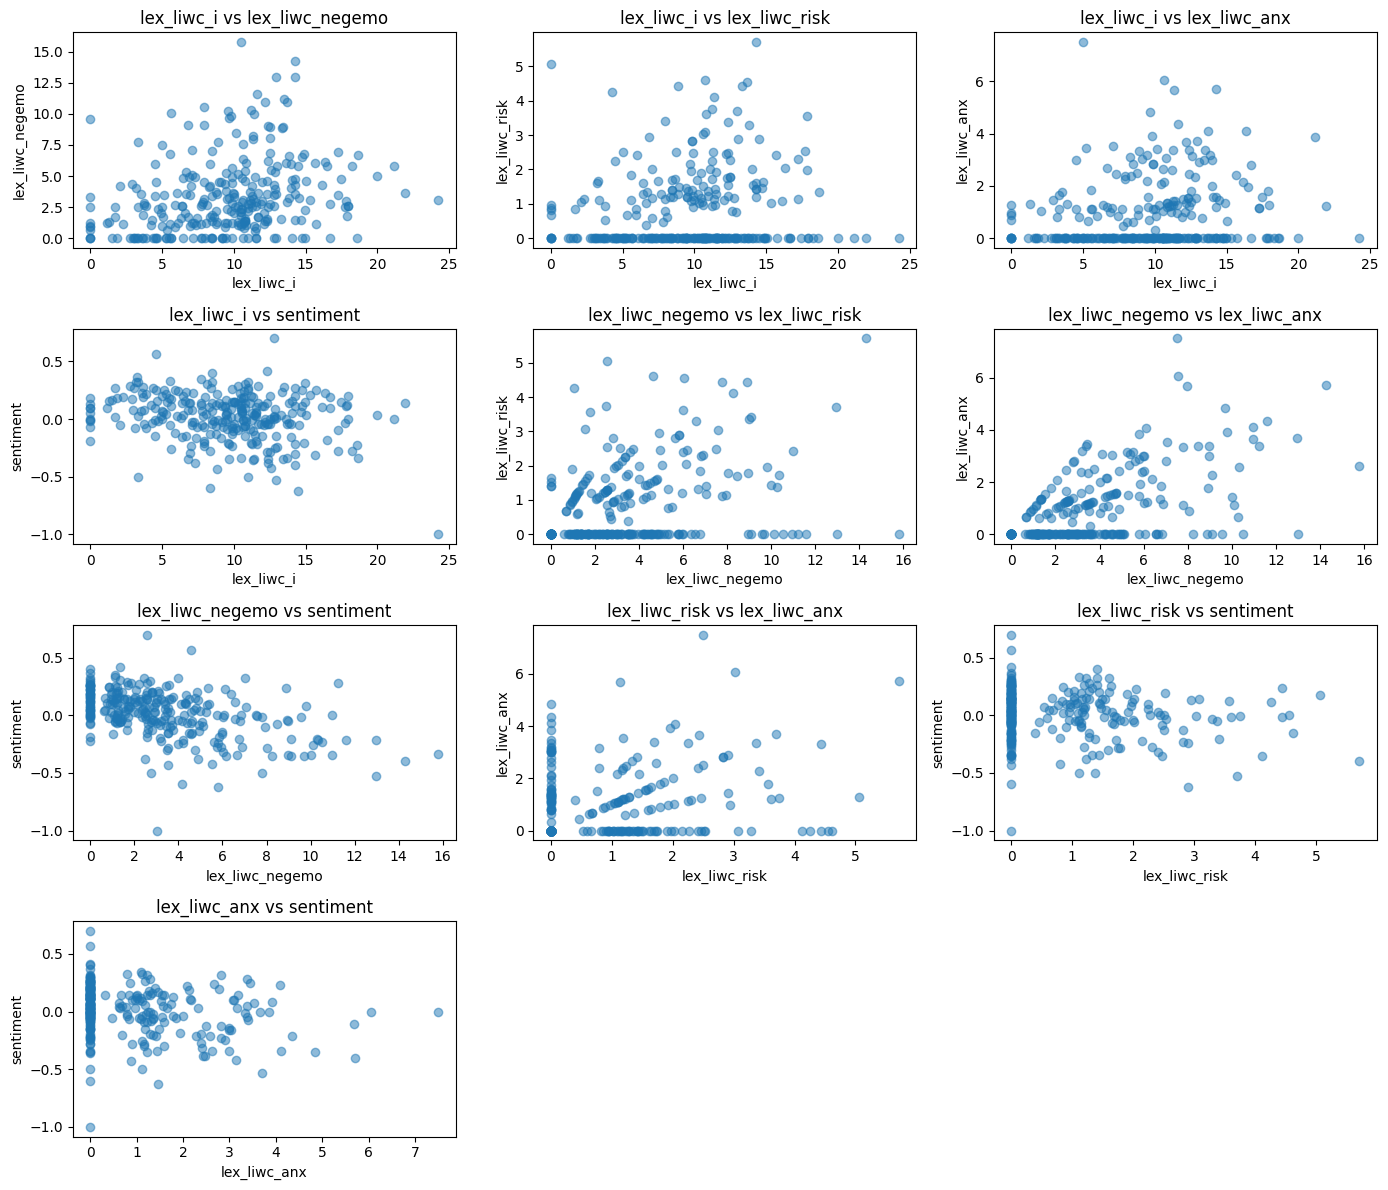

In [8]:
##GENERATED USING CHATGPT
import itertools

cols = [
    "lex_liwc_i",
    "lex_liwc_negemo",
    "lex_liwc_risk",
    "lex_liwc_anx",
    "sentiment"
]

pairs = list(itertools.combinations(cols, 2))

plt.figure(figsize=(14, 12))

for i, (x_col, y_col) in enumerate(pairs, 1):
    plt.subplot(4, 3, i)
    plt.scatter(df[x_col], df[y_col], alpha=0.5)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{x_col} vs {y_col}")

plt.tight_layout()
plt.show()
plt.close()

In [9]:
cols = [
    "lex_liwc_i",
    "lex_liwc_negemo",
    "lex_liwc_risk",
    "lex_liwc_anx",
    "sentiment"
]

corr_matrix = df[cols].corr()

corr_matrix

,lex_liwc_i,lex_liwc_negemo,lex_liwc_risk,lex_liwc_anx,sentiment
lex_liwc_i,1.000000,0.273128,0.129532,0.167287,-0.221776
lex_liwc_negemo,0.273128,1.000000,0.365157,0.596997,-0.475686
lex_liwc_risk,0.129532,0.365157,1.000000,0.285958,-0.167026
lex_liwc_anx,0.167287,0.596997,0.285958,1.000000,-0.245087
sentiment,-0.221776,-0.475686,-0.167026,-0.245087,1.000000


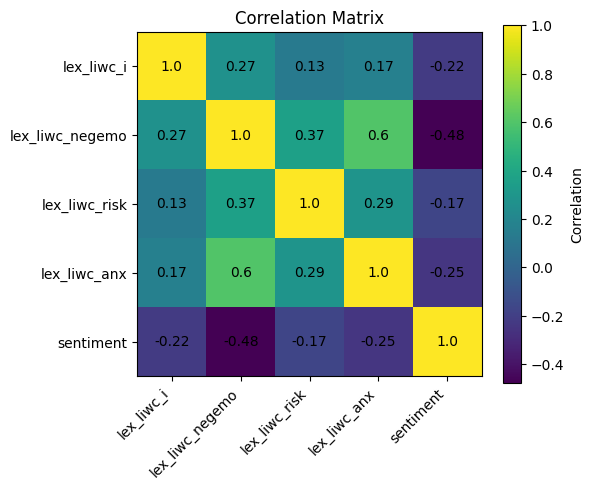

In [10]:
plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix)
plt.colorbar(label="Correlation")
plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
plt.yticks(range(len(cols)), cols)
plt.title("Correlation Matrix")

for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, round(corr_matrix.iloc[i, j], 2),
                 ha="center", va="center")

plt.tight_layout()
plt.show()